In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np
import hdbscan
from keybert import KeyBERT
from sklearn.cluster import KMeans
from collections import Counter
import matplotlib.pyplot as plt
import os
import base64   
import io

In [10]:
# 1. Cargar dataset
df = pd.read_csv("C:\\Users\\Usuario9\\OneDrive\\Documentos\\Master Big Data\\UPC - BIG DATA\\TFM\\TFM-main\\TFM-main\\datasets\\Kaggle\\csv\\DailyDialog.csv", encoding="utf-8")
texts = df['text'].astype(str).tolist()

# Identificar columnas de emociones
emotion_columns = df.columns[df.columns.get_loc("sentiment"):]

# Crear columna con la emoción principal
df['main_emotion'] = df['sentiment'].astype(str)

# Filtrar las 3 emociones más comunes
top_emotions = df["main_emotion"].value_counts().head(3).index.tolist()
df_filtered = df[df["main_emotion"].isin(top_emotions)].copy()

# Reducir el número de textos para mejor visualización
# Tomar una muestra equilibrada de cada emoción (máximo 300 textos por emoción para HDBSCAN)
sample_size_per_emotion = 300

df_sampled = pd.DataFrame()
for emotion in top_emotions:
    emotion_data = df_filtered[df_filtered["main_emotion"] == emotion]
    if len(emotion_data) > sample_size_per_emotion:
        emotion_sample = emotion_data.sample(n=sample_size_per_emotion, random_state=42)
    else:
        emotion_sample = emotion_data
    df_sampled = pd.concat([df_sampled, emotion_sample], ignore_index=True)

print(f"Analizando {len(df_sampled)} textos de las emociones: {top_emotions}")

# 3. Generar embeddings y clustering
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = model.encode(df_sampled["text"].tolist(), show_progress_bar=True)

Analizando 900 textos de las emociones: ['joy', 'sadness', 'anger']


Batches: 100%|██████████| 29/29 [00:08<00:00,  3.49it/s]


In [11]:
# UMAP + HDBSCAN
umap_reducer = umap.UMAP(n_components=2, metric="cosine", n_neighbors=15, min_dist=0.0, random_state=42)
umap_2d = umap_reducer.fit_transform(embeddings)

hdb_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,     # Aumentar de 15 a 30
    min_samples=10,          # Añadir min_samples
    cluster_selection_epsilon=0.2  # Control de granularidad
)
cluster_labels = hdb_clusterer.fit_predict(umap_2d)


c:\Users\Usuario9\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
# 4. Extraer palabras clave con KeyBERT
print("\nExtrayendo palabras clave...")
kw_model = KeyBERT(model=model)
cluster_keywords = {}

for cluster_id in np.unique(cluster_labels):
    if cluster_id == -1:  # Saltar ruido
        continue
    cluster_docs = [df_sampled["text"].iloc[i] for i in range(len(cluster_labels)) if cluster_labels[i] == cluster_id]
    cluster_text = " ".join(cluster_docs)
    keywords = kw_model.extract_keywords(cluster_text, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=8)
    cluster_keywords[cluster_id] = [kw[0] for kw in keywords]


Extrayendo palabras clave...


In [13]:
# 5. Resultados y visualización
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"\n🎯 RESULTADOS: {n_clusters} clusters encontrados")

# Información por cluster
for i in range(n_clusters):
    cluster_data = df_sampled[cluster_labels == i]
    emotion_dist = cluster_data["main_emotion"].value_counts()
    keywords = cluster_keywords.get(i, [])
    
    print(f"\n📊 Cluster {i} ({len(cluster_data)} textos):")
    print(f"   Emociones: {dict(emotion_dist)}")
    print(f"   Keywords: {keywords}")


🎯 RESULTADOS: 5 clusters encontrados

📊 Cluster 0 (96 textos):
   Emociones: {'joy': 49, 'sadness': 27, 'anger': 20}
   Keywords: ['failed exam', 'failed exams', 'succeeded examinations', 'examination failed', 'failed examination', 'exams expected', 'passed exams', 'exam unfairly']

📊 Cluster 1 (189 textos):
   Emociones: {'joy': 72, 'sadness': 59, 'anger': 58}
   Keywords: ['chinese painting', 'style painting', 'painting', 'painting prefer', 'painting nice', 'sketches', 'designs', 'preliminary sketches']

📊 Cluster 2 (133 textos):
   Emociones: {'sadness': 46, 'anger': 44, 'joy': 43}
   Keywords: ['gratification anne', 'sympathetic amused', 'telling delighted', 'fondly anne', 'revealing gratification', 'amused glance', 'amused', 'anne']

📊 Cluster 3 (88 textos):
   Emociones: {'anger': 75, 'sadness': 12, 'joy': 1}
   Keywords: ['mother insulted', 'insulted mother', 'beaten mother', 'mother quarrelled', 'assaulted threatening', 'punching child', 'father beaten', 'child beaten']

📊 Clu

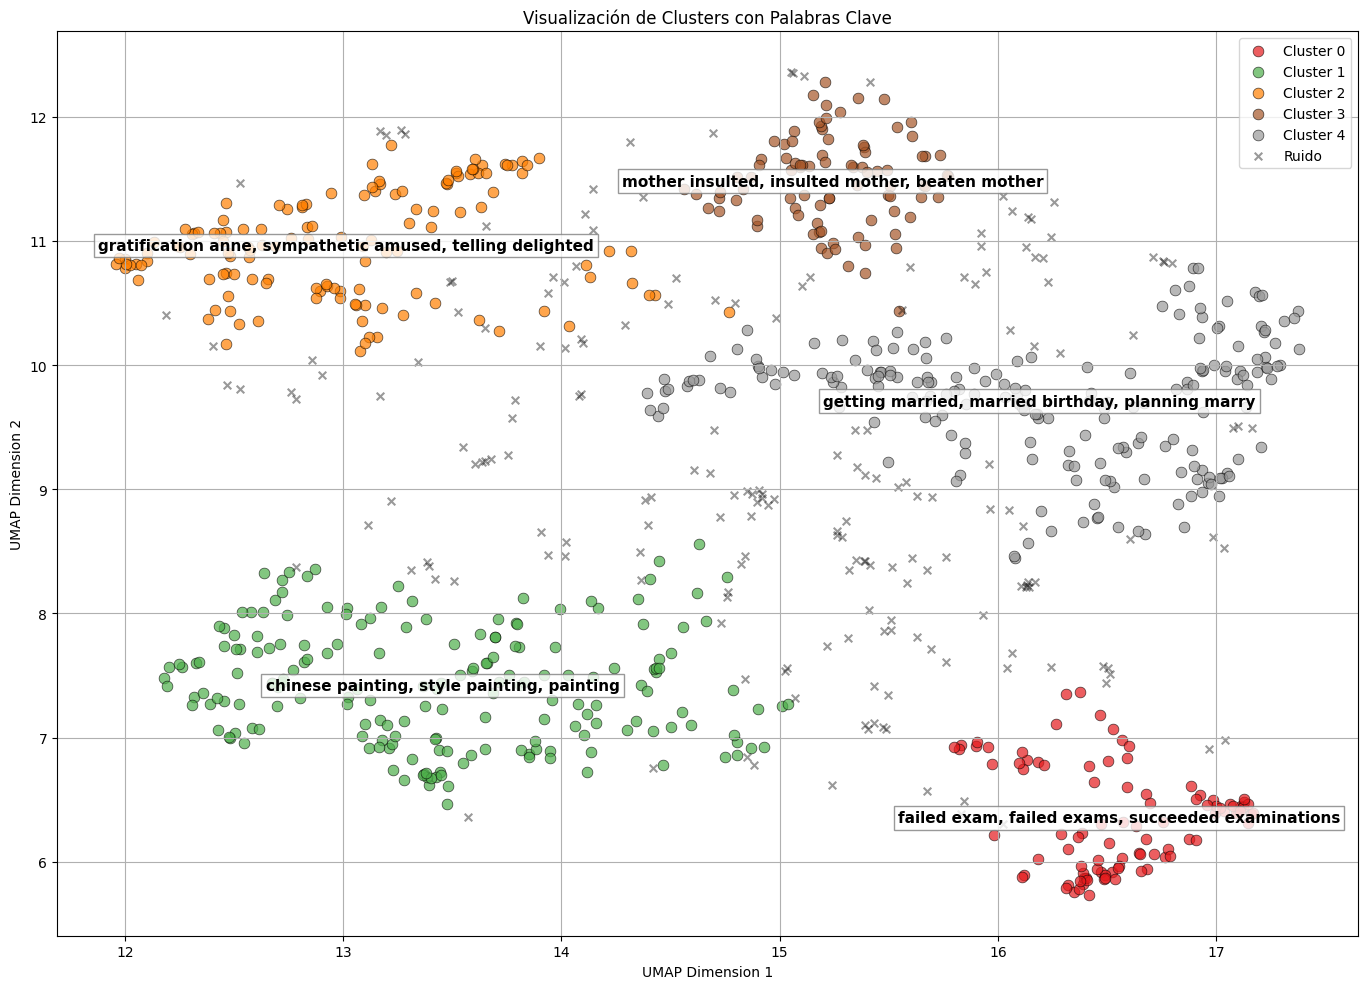

In [ ]:
# 6. Visualización con palabras clave

def generar_grafico_clusters(umap_2d, cluster_labels, cluster_keywords):
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    plt.figure(figsize=(14, 10))
    colors = plt.cm.Set1(np.linspace(0, 1, max(n_clusters, 1)))

    for i in range(n_clusters):
        cluster_mask = cluster_labels == i
        plt.scatter(umap_2d[cluster_mask, 0], umap_2d[cluster_mask, 1], 
                    c=[colors[i]], s=60, alpha=0.7, edgecolors='black', linewidth=0.5,
                    label=f"Cluster {i}")
        
        cluster_points = umap_2d[cluster_mask]
        center_x, center_y = cluster_points.mean(axis=0)
        top_keywords = ", ".join(cluster_keywords.get(i, [])[:3])
        
        plt.text(center_x, center_y, top_keywords, fontsize=11, weight='bold',
                 ha='center', va='center', 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=3))

    if -1 in cluster_labels:
        noise_mask = cluster_labels == -1
        plt.scatter(umap_2d[noise_mask, 0], umap_2d[noise_mask, 1], 
                    c='black', s=30, alpha=0.4, marker='x', label='Ruido')

    plt.legend()
    plt.title("Visualización de Clusters con Palabras Clave")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)
    plt.tight_layout()

    # 🔁 Convertir el gráfico a base64
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    image_base64 = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    return image_base64
